# LLM Football Benchmark — Analysis

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

os.makedirs("../results", exist_ok=True)

COLORS = {"groq-llama": "#6C8EBF", "groq-llama70b": "#82B366"}
LABELS = {"groq-llama": "Llama 3.1 8B", "groq-llama70b": "Llama 3.3 70B"}
MODELS = ["groq-llama", "groq-llama70b"]

plt.rcParams.update({"figure.facecolor": "#F9F9F9", "axes.facecolor": "#F9F9F9",
                     "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.5})

## Load & merge data

In [2]:
responses = pd.read_csv("../data/responses.csv")
scores = pd.read_csv("../data/judge_scores.csv")

df = responses.merge(scores[["question_id", "model", "judge_score", "judge_explanation"]],
                     on=["question_id", "model"])

# Drop the two malformed rows where difficulty was corrupted
df = df[df["difficulty"].isin(["easy", "medium", "hard"])]

df["model_label"] = df["model"].map(LABELS)
print(f"Rows: {len(df)}")
df.head()

Rows: 138


,question_id,category,difficulty,model,response,timestamp,judge_score,judge_explanation,model_label
0,Q001,CONCEPT,easy,groq-llama,The offside rule in football is a crucial part...,2026-05-20T07:56:30.747121+00:00,5,The response provides an accurate and detailed...,Llama 3.1 8B
1,Q001,CONCEPT,easy,groq-llama70b,The offside rule in football is a regulation t...,2026-05-20T07:58:04.622342+00:00,6,The response provides an accurate and clear de...,Llama 3.3 70B
2,Q002,CONCEPT,medium,groq-llama,"A pressing strategy, also known as high-pressi...",2026-05-20T07:58:06.767708+00:00,6,"The response provides an accurate, clear defin...",Llama 3.1 8B
3,Q002,CONCEPT,medium,groq-llama70b,"A pressing strategy, also known as ""pressing"" ...",2026-05-20T07:58:10.046677+00:00,7,"The response provides an accurate, clear defin...",Llama 3.3 70B
4,Q003,CONCEPT,hard,groq-llama,The main difference between a False 9 and a tr...,2026-05-20T07:58:12.195166+00:00,7,The response provides a clear and accurate def...,Llama 3.1 8B


## 1 — Overall average score per model

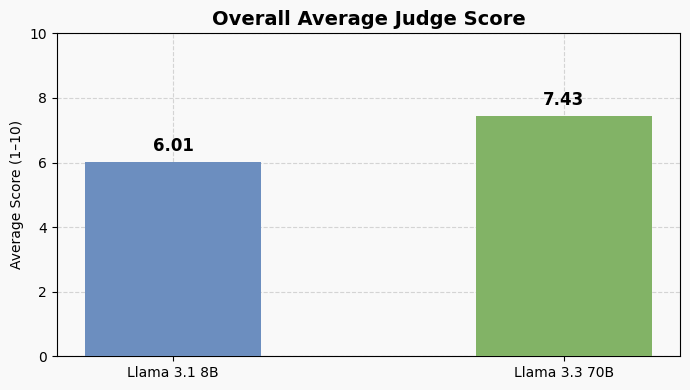

In [3]:
overall = df.groupby("model")["judge_score"].mean().reindex(MODELS)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([LABELS[m] for m in MODELS], overall.values,
              color=[COLORS[m] for m in MODELS], width=0.45, zorder=3)
ax.bar_label(bars, fmt="%.2f", padding=5, fontsize=12, fontweight="bold")
ax.set_ylim(0, 10)
ax.set_title("Overall Average Judge Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/01_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Score by category

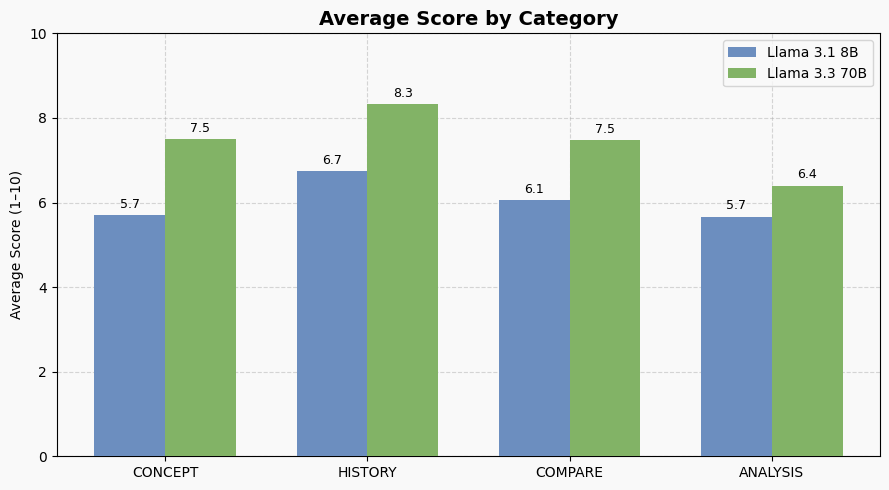

In [4]:
import numpy as np

CATEGORIES = ["CONCEPT", "HISTORY", "COMPARE", "ANALYSIS"]
cat_pivot = (df.groupby(["model", "category"])["judge_score"]
               .mean()
               .unstack("category")
               .reindex(MODELS)[CATEGORIES])

x = np.arange(len(CATEGORIES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, model in enumerate(MODELS):
    vals = cat_pivot.loc[model]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=LABELS[model], color=COLORS[model], zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.set_ylim(0, 10)
ax.set_title("Average Score by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/02_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 — Score by difficulty

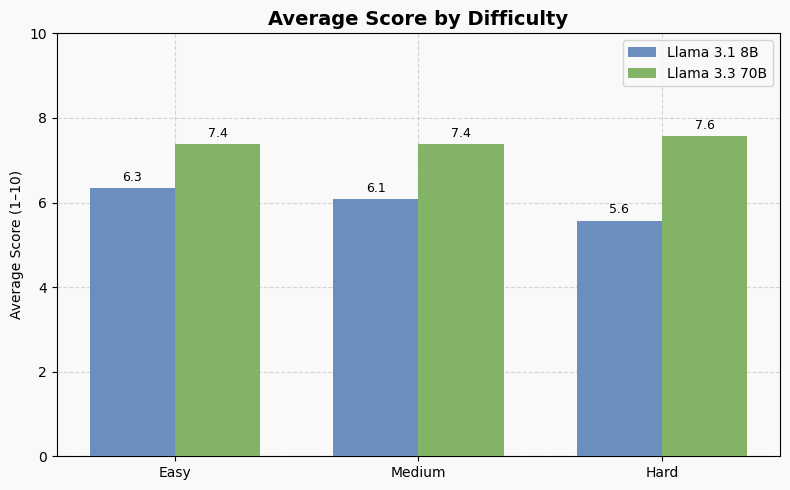

In [5]:
DIFFICULTIES = ["easy", "medium", "hard"]
diff_pivot = (df.groupby(["model", "difficulty"])["judge_score"]
                .mean()
                .unstack("difficulty")
                .reindex(MODELS)[DIFFICULTIES])

x = np.arange(len(DIFFICULTIES))

fig, ax = plt.subplots(figsize=(8, 5))
for i, model in enumerate(MODELS):
    vals = diff_pivot.loc[model]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=LABELS[model], color=COLORS[model], zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DIFFICULTIES])
ax.set_ylim(0, 10)
ax.set_title("Average Score by Difficulty", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/03_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Score distribution

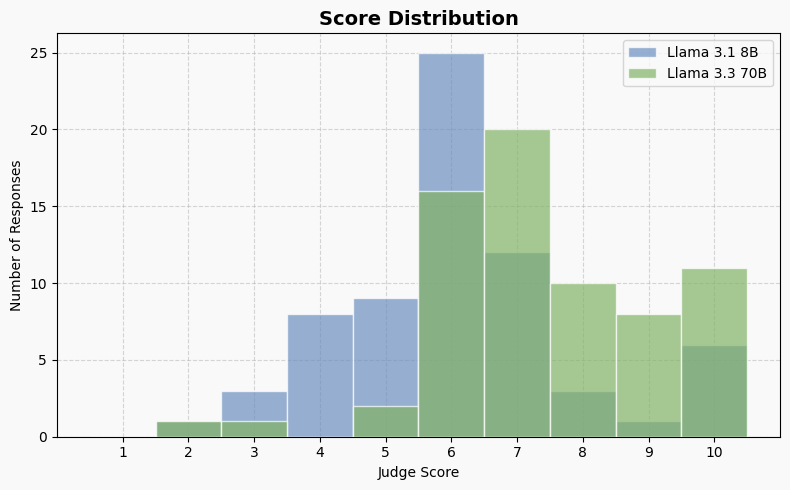

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = range(1, 12)
for model in MODELS:
    scores = df[df["model"] == model]["judge_score"]
    ax.hist(scores, bins=bins, alpha=0.7, label=LABELS[model],
            color=COLORS[model], edgecolor="white", align="left", zorder=3)

ax.set_xticks(range(1, 11))
ax.set_title("Score Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Judge Score")
ax.set_ylabel("Number of Responses")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/04_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Summary

In [7]:
overall_means = df.groupby("model")["judge_score"].mean()
best_overall = LABELS[overall_means.idxmax()]

cat_means = df.groupby(["category", "model"])["judge_score"].mean().unstack("model")
best_per_cat = {cat: LABELS[row.idxmax()] for cat, row in cat_means.iterrows()}

gaps = (df.groupby(["category", "model"])["judge_score"]
          .mean()
          .unstack("model")
          .assign(gap=lambda d: (d["groq-llama70b"] - d["groq-llama"]).abs()))
biggest_gap_cat = gaps["gap"].idxmax()
biggest_gap_val = gaps["gap"].max()

print("=" * 50)
print(f"  Best model overall:       {best_overall}")
print(f"    Llama 3.1 8B  avg:      {overall_means['groq-llama']:.2f}")
print(f"    Llama 3.3 70B avg:      {overall_means['groq-llama70b']:.2f}")
print()
print("  Best model per category:")
for cat, winner in best_per_cat.items():
    m1, m2 = cat_means.loc[cat, "groq-llama"], cat_means.loc[cat, "groq-llama70b"]
    print(f"    {cat:10s}  →  {winner}  ({m1:.1f} vs {m2:.1f})")
print()
print(f"  Biggest score gap:        {biggest_gap_cat}  ({biggest_gap_val:.2f} pts)")
print("=" * 50)

  Best model overall:       Llama 3.3 70B
    Llama 3.1 8B  avg:      6.01
    Llama 3.3 70B avg:      7.43

  Best model per category:
    ANALYSIS    →  Llama 3.3 70B  (5.7 vs 6.4)
    COMPARE     →  Llama 3.3 70B  (6.1 vs 7.5)
    CONCEPT     →  Llama 3.3 70B  (5.7 vs 7.5)
    HISTORY     →  Llama 3.3 70B  (6.7 vs 8.3)

  Biggest score gap:        CONCEPT  (1.80 pts)
